# Modelo de agentes SEIRD

## Introdução

O modelo descrito por Weits e Dushoff (2015, https://www.nature.com/articles/srep08751) tem sua dinâmica descrita pelas seguintes equações

\begin{align}
     \frac{dS}{dt} &= -\beta_{I}SI/N - \beta_{D}SD/N \\
     \frac{dE}{dt} &= \beta_{I}SI/N + \beta_{D}SD/N - E/T_{E} \\
     \frac{dI}{dt} &= E/T_{E} - I/T_{I} \\
     \frac{dR}{dt} &= (1-f)I/T_{I} \\
     \frac{dD}{dt} &= fI/T_{I} - D/T_{D} \\
     N & = S+E+I+R
\end{align}

Onde a população está dividida entre $S$ (suscetíveis), $E$ (expostos), $I$ (infectados), $R$ (removidos) e $D$ (mortos). A população total ($N$) não inclui mortos, apesar destes poderem infectar a população suscetível.

$f$ é a fração de mortes de infectados.

\begin{align}
     S \rightarrow I, \quad & p_{SI\_I} = \frac{\beta_{I} I}{N} \Delta t \\
     S \rightarrow I, \quad & p_{SI\_D} = \frac{\beta_{D} D}{N} \Delta t\\
     E \rightarrow I, \quad & p_{EI} = \frac{1}{T_{E}} \Delta t \\
     I \rightarrow R, \quad & p_{IR} = \frac{1-f}{T_{I}} \Delta t \\
     I \rightarrow D, \quad & p_{ID} = \frac{f}{T_{I}} \Delta t \\
     D \rightarrow \varnothing, \quad & p_{D} = \frac{1}{T_{D}} \Delta t
\end{align}

Existem dois caminhos para que os sucetíveis sejam infectados: pelo contato com a população infectada viva ($I$) ou morta ($D$). Na realidade, uma pessoa poderia ter contato tanto com infectados vivos quanto mortos, e o próprio artigo menciona isso. Em casos de duplo contato é difícil distinguir qual foi o contato determinante para a causar a infecção. 

Logo, optou-se por uma aplicação de modelo baseado em agentes (MBA) que possibilitasse o contato duplo, mas ainda não distingue qual foi aquele que gerou a infecção. Isso é feito a partir de dois teste aleatórios para o mesmo grupo de sucetíveis, um teste para a infecção por infectados vivos e outra para mortos. Ao final de cada teste, verifica-se qual foi o tipo de infecção de cada agente S que se tornou I.

Resolvendo numericamente as equações diferenciais (EDO) desses sistema a quantidade de sucetíveis que se tornam expostos é $\left(-\beta_{I}SI/N - \beta_{D}SD/N \right)dt$, tratando-se de uma soma simples e desconsiderando sobreposições de infecções cuasdas por $I$ e $D$. Essa diferença entre o método MBA e EDOs é conciente e pode ser revista no futuro.

Outro ponto que merece atenção é a transição de agentes $I$ para $R$ e $D$. Da mesma forma é feito um teste com um sorteio aleatório, e a mudança de grupo é avaliada com uma espécie de "tower sampling". Primeiro se avalia quantos valores aleatórios então são menores ou iguais a $p_{IR} + p_{ID}$ e todos estes tornam-se $D$. Depois verifica-se quais são menores que $p_{IR}$, e modificam-se para $R$.

## Importando pacores e definindo objetos e funções

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
#import numba as nb

In [6]:
class SEIRD():

    # 'S' -> 0 Suscuptible
    # 'E' -> 1 Exposed
    # 'I' -> 2 Infective
    # 'R' -> 3 Removed (Immune)
    # 'D' -> 4 Dead
    # 'n' -> 5 Null (Removed by death)
    # 'ID' -> 6 Infected and Dead (See "Store types of infection")

    def __init__(self, S_i, E_i, I_i, R_i, D_i,
               beta_I, beta_D, T_E, T_I, T_D, f, dt):
        # Create object properties
        self.N = S_i + E_i + I_i + R_i
        self.beta_I = beta_I
        self.beta_D = beta_D
        self.T_E = T_E
        self.T_I = T_I
        self.T_D = T_D
        self.f = f
        self.dt = dt

        # Calculate constant change probabilities
        self.p_EI = dt/T_E
        self.p_IR = dt * (1-f)/T_I
        self.p_ID = dt * f/T_D
        self.p_D = dt/T_D

        # Create list with groups values
        self.S_serie = [S_i]
        self.E_serie = [E_i]
        self.I_serie = [I_i]
        self.R_serie = [R_i]
        self.D_serie = [D_i]
        self.t_serie = [0.0]

        # Create agents
        state = np.array([0]*S_i + [1]*E_i + [2]*I_i + [3]*R_i + [4]*D_i)
        self.agents = state

        # Create 
        self.infection_type = np.zeros(self.N)

    def evolve(self):

        # Create temporary array
        agents_temp = self.agents

        # Get index of agents in different groups
        sus_index = np.where(agents_temp == 0)[0]
        exp_index = np.where(agents_temp == 1)[0]
        inf_index = np.where(agents_temp == 2)[0]
        dea_index = np.where(agents_temp == 4)[0]

        # Change suseptible into infected
        # Calculate change probability
        p_SI_I = self.beta_I * len(inf_index)/self.N * self.dt
        p_SI_D = self.beta_D * len(dea_index)/self.N * self.dt
        # Verify stochastic changes
        SI_I_condition = np.random.uniform(0, 1, len(sus_index)) <= p_SI_I
        SI_D_condition = np.random.uniform(0, 1, len(sus_index)) <= p_SI_D
        # Some 'S' have contact with 'I' and 'D'
        change_condition = SI_I_condition | SI_D_condition
        # Change and store states in temporary array
        suscepted_exposed = np.where(change_condition, 1, 0) 
        agents_temp[sus_index] = suscepted_exposed

        # Store types of infection
        type_temp = self.infection_type[sus_index]
        type_temp = np.where(SI_I_condition, 2, type_temp)
        type_temp = np.where(SI_D_condition, 4, type_temp)
        type_temp = np.where(SI_I_condition & SI_D_condition, 6, type_temp)
        self.infection_type[sus_index] = type_temp

        # Change exposed into infected
        change_condition = np.random.uniform(0, 1, len(exp_index)) <= self.p_EI
        exposed_infected = np.where(change_condition, 2, 1)
        agents_temp[exp_index] = exposed_infected

        # Change infected into removed and dead
        x = np.random.uniform(0,1,len(inf_index))
        cond_list = [x <= self.p_IR, x <= self.p_IR + self.p_ID]
        infected_removed_dead = np.where(cond_list[0], 3, np.where(cond_list[1], 4, 2))
        agents_temp[inf_index] = infected_removed_dead

        # Change dead into null
        change_condition = np.random.uniform(0, 1, len(dea_index)) <= self.p_D
        infected_dead = np.where(change_condition, 5, 4)
        agents_temp[dea_index] = infected_dead

        # Update agents state
        self.agents = agents_temp

        # Recalculate alive population
        self.N = np.sum(np.isin(agents_temp, [0, 1, 2, 3]))


    def step(self, steps):

        for _ in tqdm(range(steps)):

            self.evolve()
            
            states = self.agents

            S = np.sum(states == 0)
            E = np.sum(states == 1)
            I = np.sum(states == 2)
            R = np.sum(states == 3)
            D = np.sum(states == 4)

            self.S_serie.append(S)
            self.E_serie.append(E)
            self.I_serie.append(I)
            self.R_serie.append(R)
            self.D_serie.append(D)
            self.t_serie.append(self.t_serie[-1]+self.dt)


    def get_series(self):

        tt = np.asarray(self.t_serie)
        SS = np.asarray(self.S_serie)
        EE = np.asarray(self.E_serie)
        II = np.asarray(self.I_serie)
        RR = np.asarray(self.R_serie)
        DD = np.asarray(self.D_serie)

        NN = SS + EE + II + RR

        '''
        SS = SS/NN
        EE = EE/NN
        II = II/NN
        RR = RR/NN
        DD = DD/NN
        '''

        return tt, SS, EE, II, RR, DD, NN


# Função para fazer várias simulações de uma vez só
# 'params' é um array 2D com combinações de parâmetros epidêmicos
def func_sim_agents(S_i, E_i, I_i, R_i, D_i, params, dt, t_end):

    N_sims = len(params)
    N_steps = int(t_end/dt + 1)

    S_list = np.empty((N_sims, N_steps), dtype=np.float64)
    E_list = np.empty((N_sims, N_steps), dtype=np.float64)
    I_list = np.empty((N_sims, N_steps), dtype=np.float64)
    R_list = np.empty((N_sims, N_steps), dtype=np.float64)
    D_list = np.empty((N_sims, N_steps), dtype=np.float64)

    for i in range(N_sims):

        beta_I, beta_D, T_E, T_I, T_D, f, n = params[i]

        epidemic = SEIRD(S_i, E_i, I_i, R_i, D_i,
                            beta_I, beta_D, T_E, T_I, T_D, f, dt)

        epidemic.step(int(t_end/dt))

        # Coletar arrays da simulação e adicionar na lista
        tt, S, E, I, R, D, N = epidemic.get_series()

        S_list[i, :] = S
        E_list[i, :] = E
        I_list[i, :] = I
        R_list[i, :] = R
        D_list[i, :] = D

    return params, S_list, E_list, I_list, R_list, D_list

# Função para salvar simulações de várias epidemias
def save_sim(sim, name, file_format):

    match file_format:
        case 'npz':
            np.savez_compressed(name,
                    parameters = sim[0], susceptible = sim[1], exposed = sim[2],
                    infected = sim[3], removed = sim[4], dead = sim[5])

        case 'csv':
            df = pd.DataFrame({'beta_I': sim[0][:,0], 'beta_D': sim[0][:,1], 't_E': sim[0][:,2], 't_I': sim[0][:,3],
                               't_D': sim[0][:,4], 'f': sim[0][:,5], 'n_sample': sim[0][:,6],
                               'suceptible': sim[1].tolist(), 'exposed': sim[2].tolist(), 'infected': sim[3].tolist(), 
                               'removed': sim[4].tolist(), 'dead': sim[5].tolist()})
            df.to_csv('{}.csv'.format(name), index=False)



## Simulando uma epidemia

In [10]:
# Condições iniciais
N, S_i = 100000, 99990
I_i = N - S_i
E_i, R_i, D_i = 0, 0, 0

# Parâmetros epidêmicos
beta_I, beta_D = 0.25, 0.3
T_E, T_I, T_D = 11, 6, 4
f = 0.7

dt, t_end = 0.1, 600

# Criar sistema
epidemic = SEIRD(S_i, E_i, I_i, R_i, D_i, 
                        beta_I, beta_D, T_E, T_I, T_D, f, dt)

# Evoluir epidemia
epidemic.step(int(t_end/dt))

# Coletar séries
epidemic_series = epidemic.get_series()
#tt, SS, EE, II, RR, DD, NN = epidemic.get_series()

100%|██████████| 6000/6000 [00:19<00:00, 302.24it/s]


Não infectado = [2156]
Infectados por I = [54666]
Infectados por D = [43090]
Infectados por I ou D = [88]


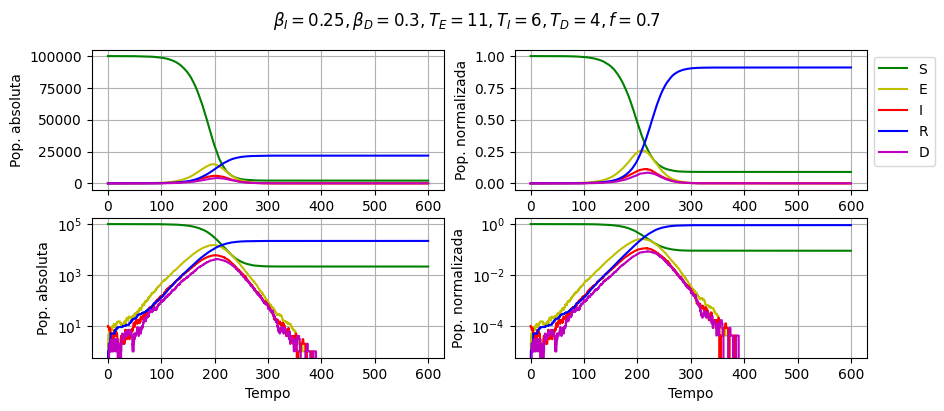

In [13]:
# Imprimir total de infecções de cada tipo
inf_type_dict = {0: 'S', 2: 'I', 4: 'D', 6: 'I ou D'}
inf_type, inf_type_count = np.unique(epidemic.infection_type, return_counts=True)
for it in inf_type:
    if it == 0:
        print('Não infectado = {}'.format(inf_type_count[inf_type == it]))
    else:
        print('Infectados por {} = {}'.format(inf_type_dict[it], inf_type_count[inf_type == it]))

# Plotar séries temporais
labels = ['S', 'E', 'I', 'R', 'D']
colors = ['g', 'y', 'r', 'b', 'm']

fig, ax = plt.subplots(2,2, figsize=(10,4))

fig.suptitle(r'$\beta_{{I}} = {}, \beta_{{D}} = {}, T_{{E}} = {}, T_{{I}} = {}, T_{{D}} = {}, f = {}$'.format(beta_I, beta_D, T_E, T_I, T_D, f))

for i in range(5):
    ax[0,0].plot(epidemic_series[0], epidemic_series[i+1], 
                label=labels[i], c=colors[i])
    ax[0,1].plot(epidemic_series[0], epidemic_series[i+1]/epidemic_series[-1], 
                label=labels[i], c=colors[i])
    ax[1,0].plot(epidemic_series[0], epidemic_series[i+1], 
                label=labels[i], c=colors[i])
    ax[1,1].plot(epidemic_series[0], epidemic_series[i+1]/epidemic_series[-1], 
                label=labels[i], c=colors[i])

ax[0,0].set(ylabel = 'Pop. absoluta')
ax[1,0].set(ylabel = 'Pop. absoluta', xlabel = 'Tempo', yscale='log')
ax[0,1].set(ylabel = 'Pop. normalizada')
ax[1,1].set(ylabel = 'Pop. normalizada', xlabel = 'Tempo', yscale='log')

for a in (ax).flat:
    a.grid()

ax[0,1].legend(loc='upper left', bbox_to_anchor=(1, 1)) 
  

## Simulando várias epidemias

In [7]:
# Condições iniciais
N, S_i = 100000, 99990
I_i = N - S_i
E_i, R_i, D_i = 0, 0, 0

# Parâmetros epidêmicos
beta_I, beta_D = np.linspace(0.05, 0.3, 6), np.linspace(0.1, 0.4, 4)
T_E, T_I, T_D = np.array([11]), np.array([6]), np.linspace(2, 6, 3)
f = np.array([0.7])

dt, t_end = 0.1, 600

sample_size = 1

t_end = 600

dt = 1e-1

params = np.array([[b_I, b_D, t_E, t_I, t_D, fi, n] 
                   for b_I in beta_I for b_D in beta_D for t_E in T_E for t_I in T_I for t_D in T_D for fi in f for n in range(sample_size)],
                    dtype = np.float64)

# Rodar simulações
sims = func_sim_agents(S_i, E_i, I_i, R_i, D_i, params, dt, t_end)

 47%|████▋     | 2829/6000 [00:16<00:18, 169.55it/s]


KeyboardInterrupt: 

In [ ]:
labels = ['S', 'E', 'I', 'R', 'D']
colors = ['g', 'y', 'r', 'b', 'm']
tt = np.arange(len(sims[1][0]))*dt

for j in range(len(sims[0])):

    NN = sims[1][j]+sims[2][j]+sims[3][j]+sims[4][j]

    fig, ax = plt.subplots(2,2, figsize=(10,4), sharex='col', layout='tight')

    fig.suptitle(r'$\beta_{{I}} = {}, \beta_{{D}} = {}, T_{{E}} = {}, T_{{I}} = {}, T_{{D}} = {}, f = {}$'.format(*sims[0][j,:-1]))

    for i in range(5):
        ax[0,0].plot(tt, sims[i+1][j], 
                    label=labels[i], c=colors[i])
        ax[0,1].plot(tt, sims[i+1][j]/NN, 
                    label=labels[i], c=colors[i])
        ax[1,0].plot(tt, sims[i+1][j], 
                    label=labels[i], c=colors[i])
        ax[1,1].plot(tt, sims[i+1][j]/NN, 
                    label=labels[i], c=colors[i])

    ax[0,0].set(ylabel = 'Pop. absoluta')
    ax[1,0].set(ylabel = 'Pop. absoluta', xlabel = 'Tempo', yscale='log')
    ax[0,1].set(ylabel = 'Pop. normalizada')
    ax[1,1].set(ylabel = 'Pop. normalizada', xlabel = 'Tempo', yscale='log')

    for a in (ax).flat:
        a.grid()

    ax[0,1].legend(loc='upper left', bbox_to_anchor=(1, 1))   

## Salvar e carregar simulações

In [ ]:
# Salvar simulações localmente
#save_sim(sim=sims, name='seird_agents_dt01_28mai2026', file_format='npz')

# Carregar simulações salvas em csv
#df_sims = pd.read_csv('seird_agents_dt01_28mai2026.csv')

# Carregar e transformar em tupla as simulações salvas em npz
#sims = np.load('seird_agents_dt01_28mai2026.npz')
#sims = tuple(sims[k] for k in sims.keys())